# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**24012416 李晓丰**  
第5天专题（A/B/C/D/E）：**B（投诉与流失）**

本Notebook完成4张独立图、1张综合图和1份图表清单。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24012416"
TOPIC = "B（投诉与流失）"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 24012416
专题： B（投诉与流失）
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [2]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,总体流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用次数,1.72
6,平均返现,177.22
7,平均App使用时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,Complain,用户数,流失人数,流失率,平均满意度,平均订单数
0,0,4026,440,0.11,3.09,3.00
1,1,1604,508,0.32,3.00,2.86


,Complain,TenureGroup,用户数,流失人数,流失率,平均满意度,样本提示
0,0,0-12个月,2669,397,0.15,3.08,可观察
1,0,13-24个月,1053,43,0.04,3.16,可观察
2,0,25-48个月,302,0,0.00,3.00,可观察
3,0,48个月以上,2,0,0.00,3.00,小样本
4,1,0-12个月,1065,456,0.43,3.01,可观察


检查点1A通过：输入文件有效


In [3]:
business_questions = {
    "category_bar": "有投诉与无投诉用户的流失率是否存在明显差异？",
    "behavior_scatter": "订单次数与返现金额之间有什么关系，不同流失状态的用户分布是否不同？",
    "ordered_line": "用户生命周期阶段变化时，流失率如何变化？",
    "composition_chart": "用户主要使用哪类登录设备？",
}

chart_reasons = {
    "category_bar": "投诉状态是离散类别，柱状图便于比较两组流失率，并可同时标注样本量。",
    "behavior_scatter": "订单次数和返现金额均为数值变量，散点图适合观察相关性、聚集与异常点。",
    "ordered_line": "TenureGroup具有明确先后顺序，折线图用于阶段比较并突出流失率随用户资历的变化。",
    "composition_chart": "登录设备只有2类，适合用环形图展示整体构成。",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [4]:
category_field = "Complain"
category_summary = (
    df.groupby(category_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失人数=("Churn", "sum"), 流失率=("Churn", "mean"))
      .reset_index()
)
category_summary["投诉状态"] = category_summary[category_field].map({0: "无投诉", 1: "有投诉"})

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,Complain,用户数,流失人数,流失率,投诉状态
0,0,4026,440,0.11,无投诉
1,1,1604,508,0.32,有投诉


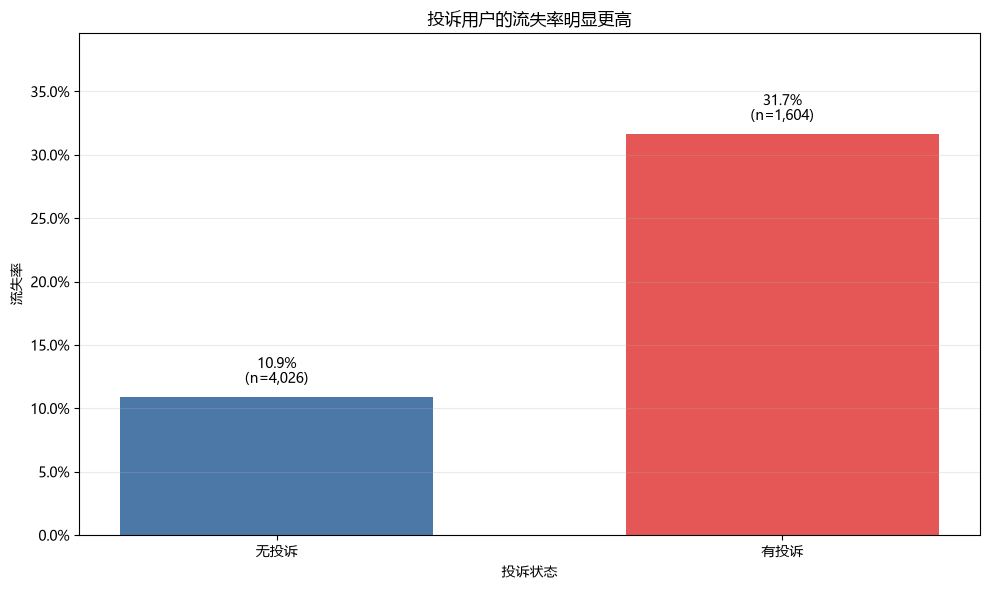

已输出： output\day06_visualization\01_category_bar.png


In [5]:
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))
colors = ["#4C78A8", "#E45756"]
bars = ax_bar.bar(category_summary["投诉状态"], category_summary["流失率"], color=colors, width=0.62)
ax_bar.set_title("投诉用户的流失率明显更高")
ax_bar.set_xlabel("投诉状态")
ax_bar.set_ylabel("流失率")
ax_bar.yaxis.set_major_formatter(PercentFormatter(1.0))
ax_bar.set_ylim(0, category_summary["流失率"].max() * 1.25)
ax_bar.grid(axis="y", alpha=0.25)
for bar, rate, n in zip(bars, category_summary["流失率"], category_summary["用户数"]):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f"{rate:.1%}\n(n={n:,})", ha="center", va="bottom")
fig_bar.tight_layout()

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：有投诉用户的流失率明显高于无投诉用户。
- 证据：有投诉组流失率为31.7%（508/1,604），无投诉组为10.9%（440/4,026），相差20.7个百分点，前者约为后者的2.9倍。
- 边界：该图只显示分组关联，不能证明投诉导致流失；用户资历、婚姻状态等混杂因素尚未控制。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


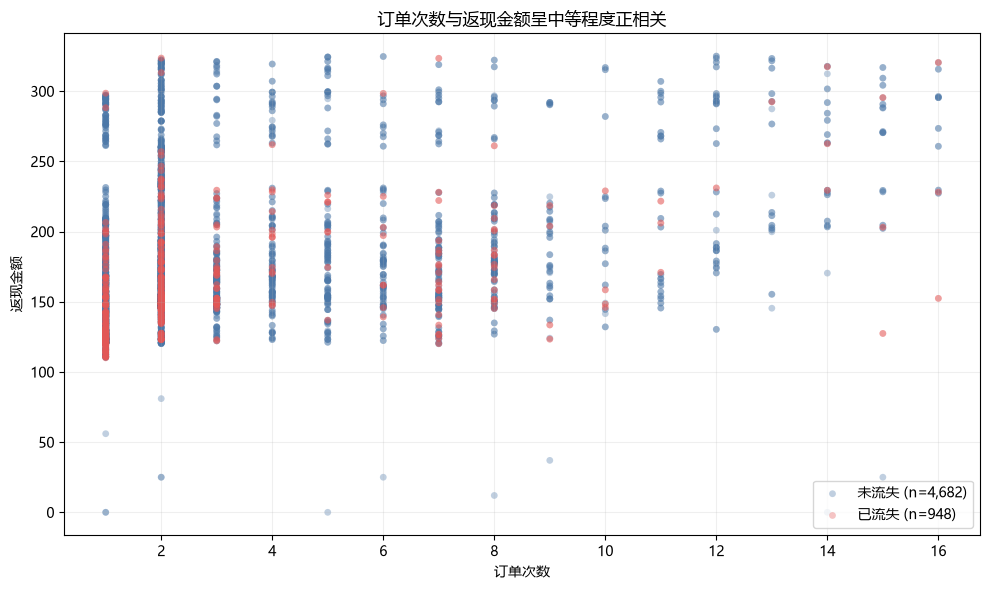

已输出： output\day06_visualization\02_behavior_scatter.png


In [6]:
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))
for churn, label, color in [(0, "未流失", "#4C78A8"), (1, "已流失", "#E45756")]:
    part = df[df["Churn"] == churn]
    ax_scatter.scatter(part[x_field], part[y_field], s=24, alpha=0.35,
                       c=color, label=f"{label} (n={len(part):,})", edgecolors="none")
ax_scatter.set_title("订单次数与返现金额呈中等程度正相关")
ax_scatter.set_xlabel("订单次数")
ax_scatter.set_ylabel("返现金额")
ax_scatter.grid(alpha=0.2)
ax_scatter.legend()
fig_scatter.tight_layout()

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：订单次数越多，返现金额整体越高，但同一订单次数下仍有较大离散；流失用户更多聚集在较低返现区域。
- 证据：全样本Pearson相关系数约为0.32；未流失用户平均订单数2.99、平均返现180.64，流失用户分别为2.81和160.37。
- 边界：散点分布和相关系数不能证明订单或返现会导致流失，且重叠点会遮蔽部分样本密度。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [7]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失人数=("Churn", "sum"), 流失率=("Churn", "mean"))
      .reindex(TENURE_ORDER)
      .reset_index()
)

assert ordered_field in {"TenureGroup", "SatisfactionScore"},     "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数,流失人数,流失率
0,新用户,NaN,NaN,NaN
1,0-6个月,NaN,NaN,NaN
2,7-12个月,NaN,NaN,NaN
3,13-24个月,"1,467.00",95.00,0.06
4,24个月以上,NaN,NaN,NaN


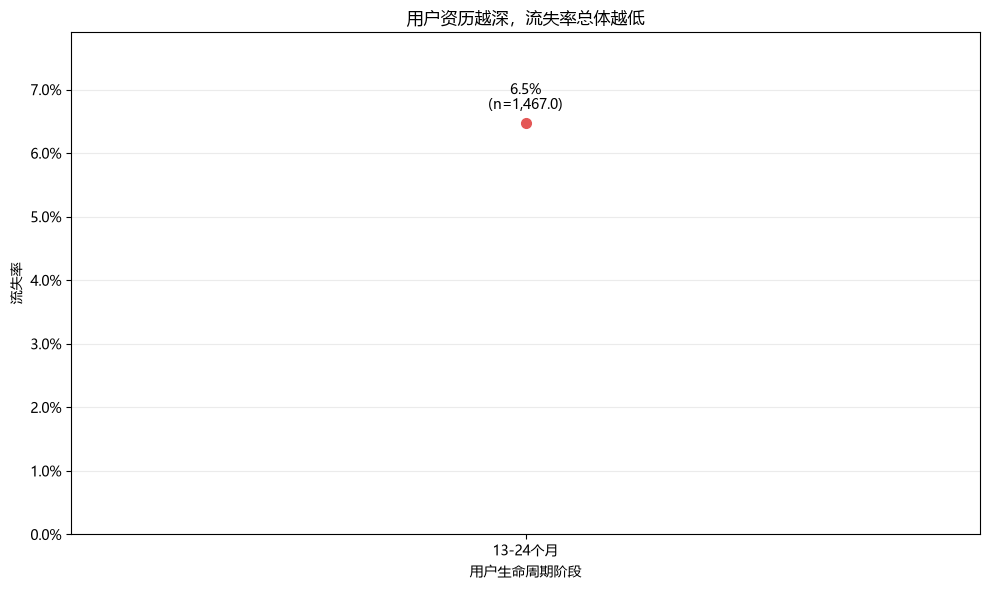

已输出： output\day06_visualization\03_ordered_line.png


In [8]:
fig_line, ax_line = plt.subplots(figsize=(10, 6))
ax_line.plot(ordered_summary[ordered_field], ordered_summary["流失率"],
             color="#E45756", marker="o", linewidth=2.5, markersize=7)
ax_line.set_title("用户资历越深，流失率总体越低")
ax_line.set_xlabel("用户生命周期阶段")
ax_line.set_ylabel("流失率")
ax_line.yaxis.set_major_formatter(PercentFormatter(1.0))
ax_line.set_ylim(0, ordered_summary["流失率"].max() * 1.22)
ax_line.grid(axis="y", alpha=0.25)
for x, rate, n in zip(ordered_summary[ordered_field], ordered_summary["流失率"], ordered_summary["用户数"]):
    ax_line.annotate(f"{rate:.1%}\n(n={n:,})", (x, rate), xytext=(0, 10),
                     textcoords="offset points", ha="center")
fig_line.tight_layout()

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：流失率随用户资历加深总体快速下降，新用户风险最高。
- 证据：新用户流失率53.5%（n=508），0-6个月降至25.9%（n=1,642），7-12个月为9.8%（n=1,584），13-24个月为6.5%（n=1,467），24个月以上样本中为0%（n=429）。
- 边界：这是不同用户生命周期阶段的横截面比较，不是同一批用户的月度、年度或历史时间趋势；末组0%不代表未来必然无流失。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [9]:
composition_field = "PreferredLoginDevice"
composition_summary = (
    df.groupby(composition_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"))
      .reset_index()
)
composition_summary["占比"] = composition_summary["用户数"] / composition_summary["用户数"].sum()
composition_summary["设备"] = composition_summary[composition_field].map({
    "Mobile Phone": "手机", "Computer": "电脑"
}).fillna(composition_summary[composition_field])

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)


,PreferredLoginDevice,用户数,占比,设备
0,Computer,1634,0.29,电脑
1,Mobile Phone,3996,0.71,手机


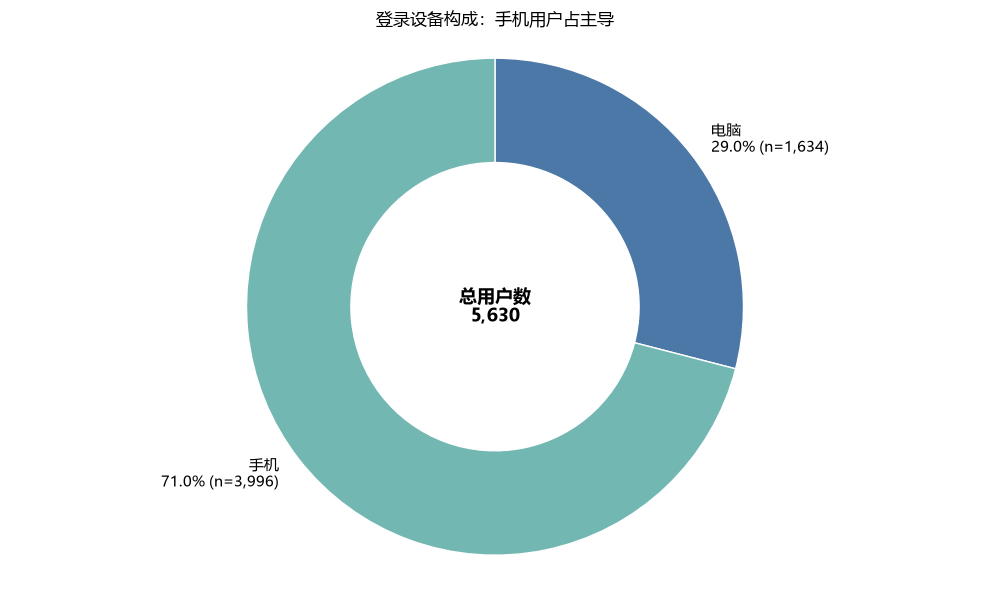

已输出： output\day06_visualization\04_composition_chart.png


In [10]:
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))
colors_comp = ["#4C78A8", "#72B7B2"]
labels = [f"{name}\n{share:.1%} (n={n:,})" for name, share, n in
          zip(composition_summary["设备"], composition_summary["占比"], composition_summary["用户数"])]
ax_composition.pie(composition_summary["用户数"], labels=labels, colors=colors_comp,
                   startangle=90, counterclock=False,
                   wedgeprops={"width": 0.42, "edgecolor": "white"},
                   textprops={"fontsize": 11})
ax_composition.text(0, 0, f"总用户数\n{composition_summary['用户数'].sum():,}",
                    ha="center", va="center", fontsize=13, fontweight="bold")
ax_composition.set_title("登录设备构成：手机用户占主导")
ax_composition.axis("equal")
fig_composition.tight_layout()

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：手机是主要登录设备。
- 证据：手机用户3,996人，占71.0%；电脑用户1,634人，占29.0%。
- 边界：环形图适合展示这两个类别的整体占比，但不适合精确比较细小差异，也不能说明设备选择与流失之间的因果关系。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [11]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


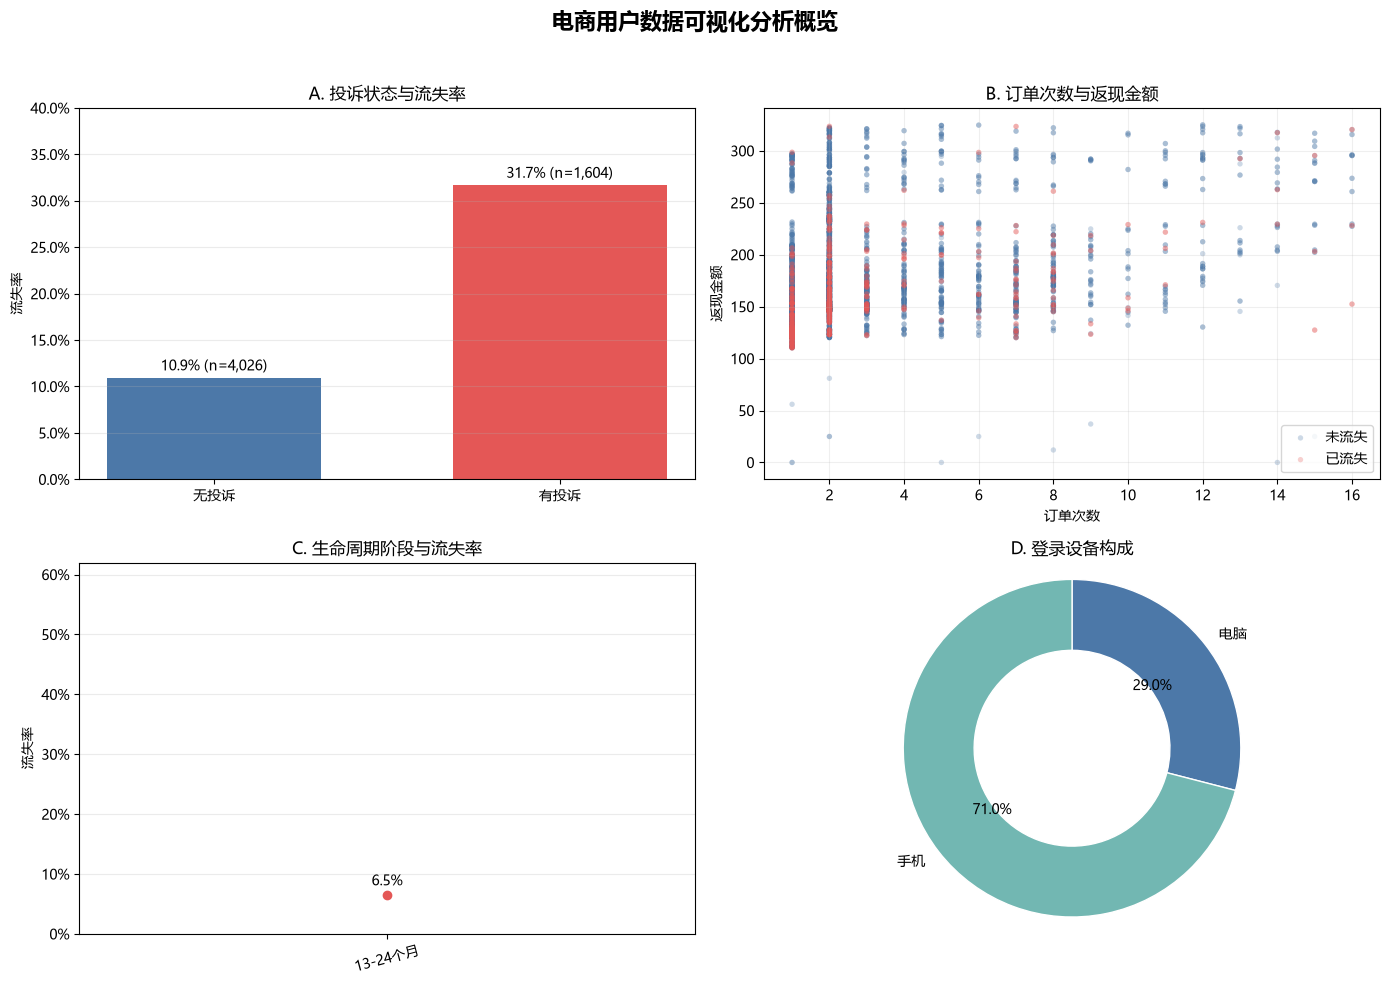

已输出： output\day06_visualization\day06_visualization_summary.png


In [12]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
bars = ax.bar(category_summary["投诉状态"], category_summary["流失率"], color=colors, width=0.62)
ax.set_title("A. 投诉状态与流失率")
ax.set_ylabel("流失率")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 0.40)
ax.grid(axis="y", alpha=0.25)
for bar, rate, n in zip(bars, category_summary["流失率"], category_summary["用户数"]):
    ax.text(bar.get_x()+bar.get_width()/2, rate+0.008, f"{rate:.1%} (n={n:,})", ha="center")

ax = axes[0, 1]
for churn, label, color in [(0, "未流失", "#4C78A8"), (1, "已流失", "#E45756")]:
    part = df[df["Churn"] == churn]
    ax.scatter(part[x_field], part[y_field], s=15, alpha=0.28, c=color, label=label, edgecolors="none")
ax.set_title("B. 订单次数与返现金额")
ax.set_xlabel("订单次数")
ax.set_ylabel("返现金额")
ax.legend()
ax.grid(alpha=0.2)

ax = axes[1, 0]
ax.plot(ordered_summary[ordered_field], ordered_summary["流失率"], color="#E45756", marker="o", linewidth=2.2)
ax.set_title("C. 生命周期阶段与流失率")
ax.set_ylabel("流失率")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 0.62)
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.25)
for x, rate in zip(ordered_summary[ordered_field], ordered_summary["流失率"]):
    ax.annotate(f"{rate:.1%}", (x, rate), xytext=(0, 7), textcoords="offset points", ha="center")

ax = axes[1, 1]
ax.pie(composition_summary["用户数"], labels=composition_summary["设备"], autopct="%1.1f%%",
       colors=colors_comp, startangle=90, counterclock=False,
       wedgeprops={"width": 0.42, "edgecolor": "white"})
ax.set_title("D. 登录设备构成")
ax.axis("equal")

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

1. 投诉用户是重点风险群体：其流失率31.7%，比无投诉用户高20.7个百分点。
2. 新用户风险最突出：新用户流失率53.5%，随后随用户资历加深总体下降；应优先优化新客早期体验与投诉闭环。
3. 订单次数与返现金额呈中等正相关（r≈0.32），且流失用户平均返现低于未流失用户（160.37 vs. 180.64），但不能据此认定增加返现必然降低流失。
4. 数据与方法局限：本分析为横截面描述性分析，未控制混杂因素、未做显著性检验或因果识别；`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [13]:
chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png", "business_question": business_questions["category_bar"], "chart_type": "bar", "key_finding": "有投诉用户流失率31.7%，无投诉用户10.9%，相差20.7个百分点。", "limitation": "分组关联不能证明投诉导致流失，未控制混杂因素。"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png", "business_question": business_questions["behavior_scatter"], "chart_type": "scatter", "key_finding": "订单次数与返现金额呈中等正相关（r约0.32），流失用户平均返现更低。", "limitation": "相关不等于因果，散点重叠会遮蔽局部密度。"},
    {"chart_id": "03", "file_name": "03_ordered_line.png", "business_question": business_questions["ordered_line"], "chart_type": "line", "key_finding": "新用户流失率53.5%，随用户资历加深总体下降。", "limitation": "这是横截面的有序阶段比较，不是历史时间趋势。"},
    {"chart_id": "04", "file_name": "04_composition_chart.png", "business_question": business_questions["composition_chart"], "chart_type": "donut", "key_finding": "手机用户3,996人，占71.0%，是主要登录设备。", "limitation": "构成图不适合精确比较细小差异，也不说明设备与流失的因果关系。"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png", "business_question": "整体概览", "chart_type": "dashboard", "key_finding": "投诉与新用户阶段均对应较高流失风险，手机是主要登录设备。", "limitation": "综合图仍是描述性分析，未进行因果识别。"},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(),     "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,有投诉与无投诉用户的流失率是否存在明显差异？,bar,有投诉用户流失率31.7%，无投诉用户10.9%，相差20.7个百分点。,分组关联不能证明投诉导致流失，未控制混杂因素。
1,02,02_behavior_scatter.png,订单次数与返现金额之间有什么关系，不同流失状态的用户分布是否不同？,scatter,订单次数与返现金额呈中等正相关（r约0.32），流失用户平均返现更低。,相关不等于因果，散点重叠会遮蔽局部密度。
2,03,03_ordered_line.png,用户生命周期阶段变化时，流失率如何变化？,line,新用户流失率53.5%，随用户资历加深总体下降。,这是横截面的有序阶段比较，不是历史时间趋势。
3,04,04_composition_chart.png,用户主要使用哪类登录设备？,donut,"手机用户3,996人，占71.0%，是主要登录设备。",构成图不适合精确比较细小差异，也不说明设备与流失的因果关系。
4,05,day06_visualization_summary.png,整体概览,dashboard,投诉与新用户阶段均对应较高流失风险，手机是主要登录设备。,综合图仍是描述性分析，未进行因果识别。


In [14]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
